# scRNA-seq A→Z (10x → Scanpy)
Objectif : QC → doublets → clustering → annotation → marqueurs → exports.


In [1]:
import scanpy as sc, anndata as ad
import numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt
import os, sys, json, platform, datetime as dt

sc.settings.verbosity = 3
sc.set_figure_params(dpi=120)
sc.settings.figdir = "figures"
sc.settings.file_format_figs = "png"    # <— force le PNG
os.makedirs(sc.settings.figdir, exist_ok=True)
plt.rcParams["savefig.format"] = "png"


print("Run at:", dt.datetime.now().isoformat())
sc.logging.print_header()


Run at: 2025-08-11T14:39:55.750898


Package,Version
scanpy,1.11.1
anndata,0.11.4
numpy,2.1.3
pandas,2.2.3
scipy,1.15.2
matplotlib,3.10.1
Component,Info
Python,"3.11.2 (main, Aug 26 2024, 07:20:54) [GCC 12.2.0]"
OS,Linux-6.1.0-17-amd64-x86_64-with-glibc2.36
CPU,38 logical CPU cores


In [2]:
#Chargement du fichier HDF5
adata = sc.read_10x_h5("./../runs/filtered_feature_bc_matrix.h5")

#Ajout d'un nom à l'objet AnnData (utile si plusieurs datasets)
adata.var_names_make_unique()

#Affichage de la structure de l'objet
adata

reading ./../runs/filtered_feature_bc_matrix.h5
 (0:00:02)


/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10645 × 38606
    var: 'gene_ids', 'feature_types', 'genome'

###  QC de base (gènes mitochondriaux/ribosomaux/hémoglobine)

In [3]:
vnames = adata.var_names

mt_mask  = vnames.str.startswith("MT-") | vnames.str.startswith("mt-")
rpl_mask = vnames.str.upper().str.startswith("RPL")
rps_mask = vnames.str.upper().str.startswith("RPS")
hb_mask  = vnames.str.upper().str.startswith(("HBA","HBB","HBD","HBE","HBG"))

adata.var["mt"]   = mt_mask
adata.var["ribo"] = rpl_mask | rps_mask
adata.var["hb"]   = hb_mask

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt","ribo","hb"], inplace=True)


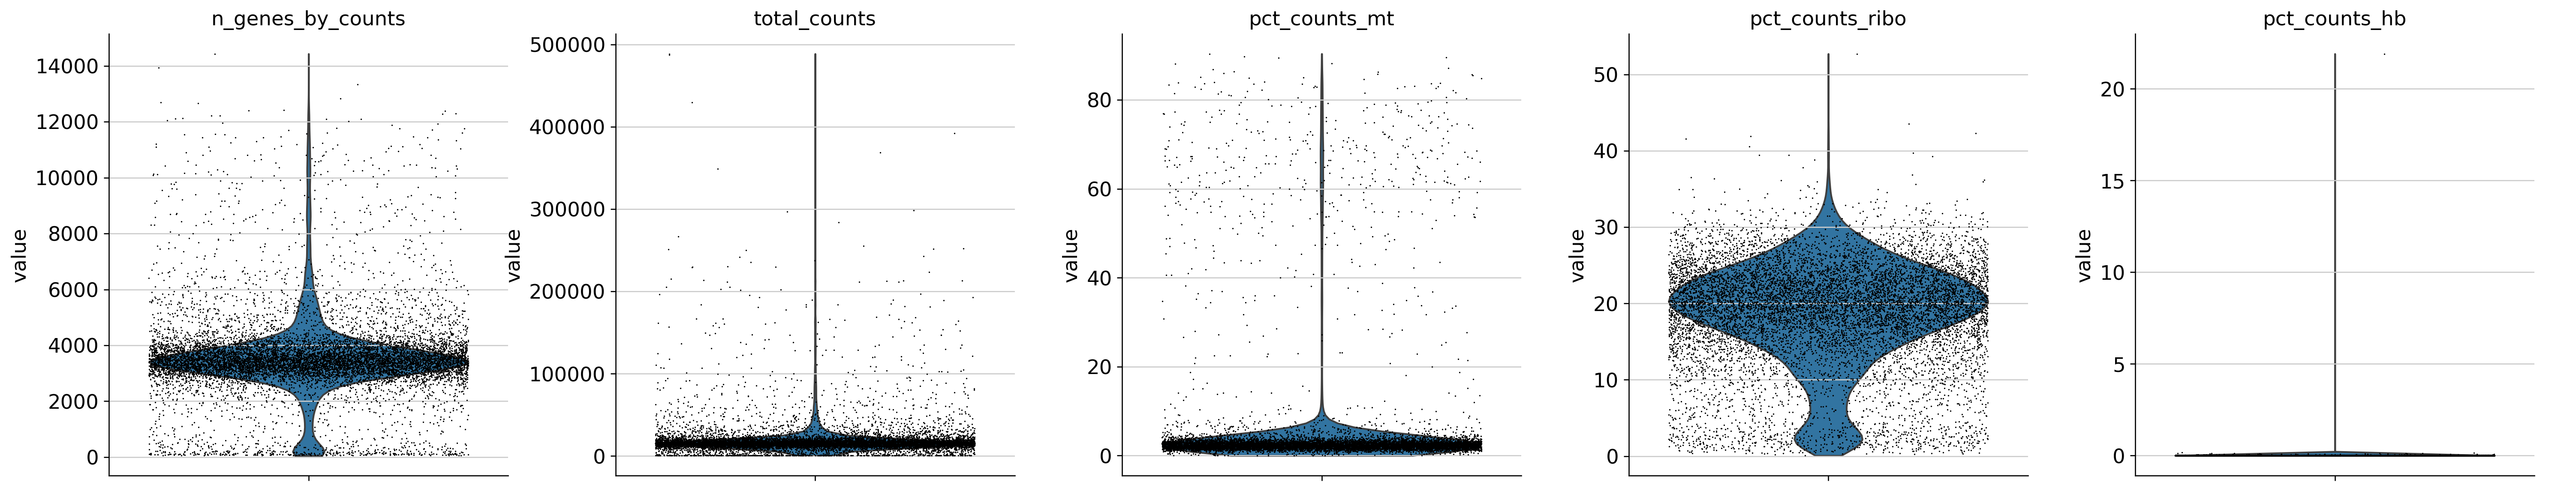

In [4]:
sc.pl.violin(
    adata, ["n_genes_by_counts","total_counts","pct_counts_mt","pct_counts_ribo","pct_counts_hb"],
    jitter=0.4, multi_panel=True, show=False
); plt.show()


### Filtrage data-driven simple

## 3) Filtrage
- Règle simple (à ajuster ensuite au besoin) :
  - garder cellules avec `n_genes_by_counts` dans [1ᵉʳ, 99ᵉ] centiles
  - `pct_counts_mt` < 20 %


In [5]:
q1, q99 = np.percentile(adata.obs["n_genes_by_counts"], [1, 99])
keep = (
    (adata.obs["n_genes_by_counts"] >= q1) &
    (adata.obs["n_genes_by_counts"] <= q99) &
    (adata.obs["pct_counts_mt"] < 20)
)
adata = adata[keep].copy()
adata


AnnData object with n_obs × n_vars = 10031 × 38606
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

### Détection de doublets (Scrublet)

## 4) Doublets (Scrublet)
- **Important** sur tissus solides.  
- Si `scrublet` n'est pas installé : `pip install scrublet`


In [6]:
import scrublet as scr

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.43
Detected doublet rate = 1.8%
Estimated detectable doublet fraction = 45.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.0%
Elapsed time: 37.6 seconds


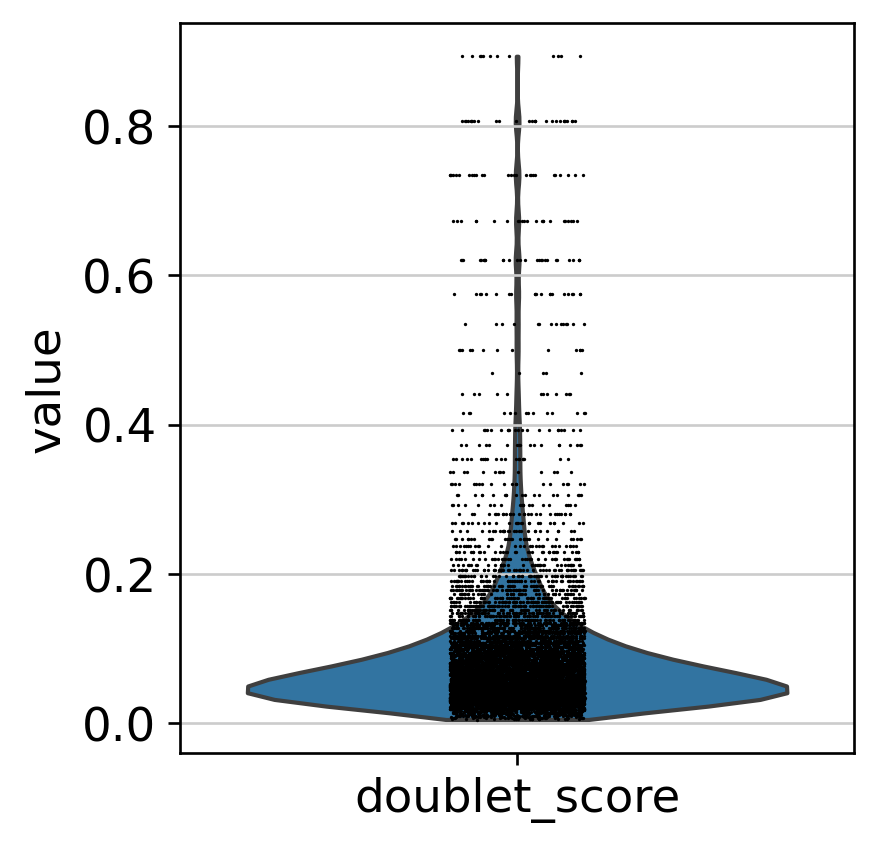

In [7]:
# Scrublet attend une matrice counts (non log-normalisée)
counts = adata.X
if not sp.issparse(counts):
    counts = sp.csr_matrix(counts)

scrub = scr.Scrublet(counts)
doublet_scores, doublet_preds = scrub.scrub_doublets()

adata.obs["doublet_score"] = doublet_scores
adata.obs["doublet_call"]  = doublet_preds.astype(bool)

sc.pl.violin(adata, ["doublet_score"], groupby=None, show=False); plt.show()


In [8]:
# Filtrage conservateur : retire les doublets prédits
adata = adata[~adata.obs["doublet_call"]].copy()
adata


AnnData object with n_obs × n_vars = 9848 × 38606
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'doublet_call'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

### Normalisation, log, HVGs, sauvegarde de la matrice "raw"
#### 5) Normalisation & HVGs
- Normalise à 10k UMI / cellule, log1p
- Sélection des gènes hautement variables (Seurat v3)
- On conserve la matrice normalisée complète dans `adata.raw` pour la DE


In [9]:
# Installer la dépendance nécessaire à seurat_v3
%pip install -q --upgrade scikit-misc


Note: you may need to restart the kernel to use updated packages.


In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
adata.raw = adata  # garde l'expression normalisée/log pour la DE

adata = adata[:, adata.var["highly_variable"]].copy()


normalizing counts per cell


    finished (0:00:00)
extracting highly variable genes


/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:73: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


### Réduction de dimension, voisins, UMAP, clustering

computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 50


2025-08-11 14:41:34.190153: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-11 14:41:34.196697: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-11 14:41:34.211154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754916094.234889 3510404 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754916094.242889 3510404 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754916094.265215 3510404 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:44)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:31)
running Leiden clustering


/tmp/ipykernel_3510404/3967027028.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="leiden", resolution=1.0)


    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:06)


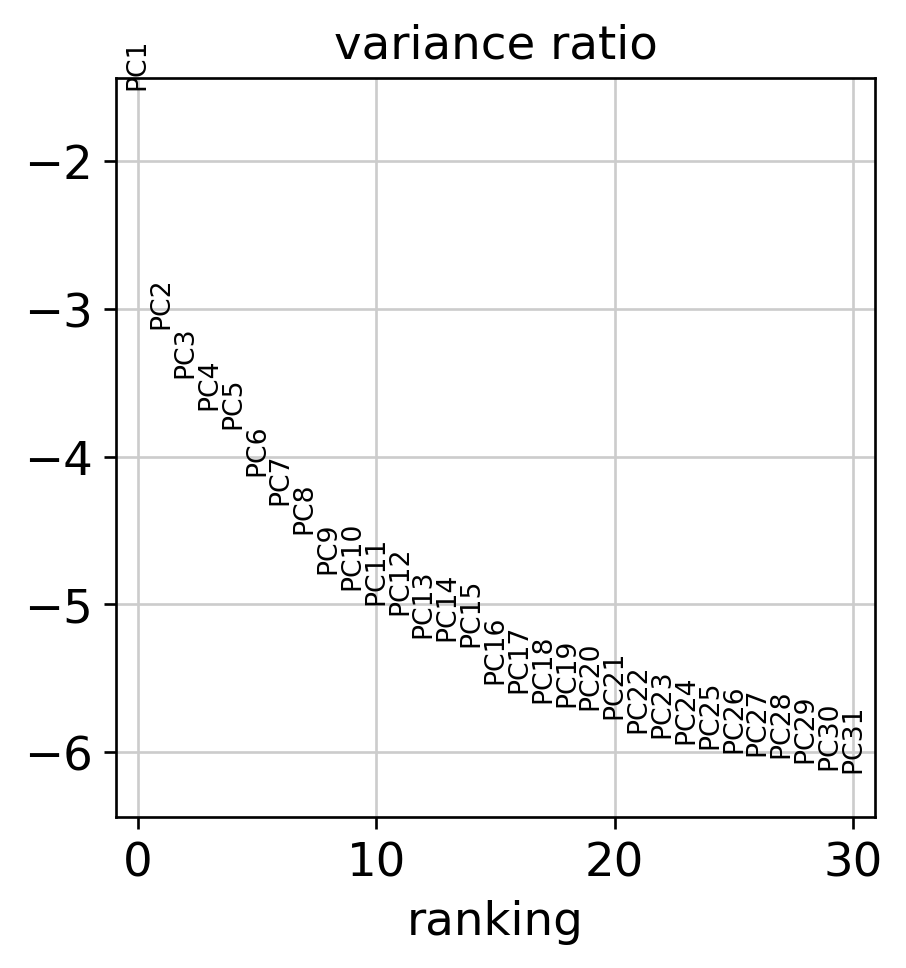

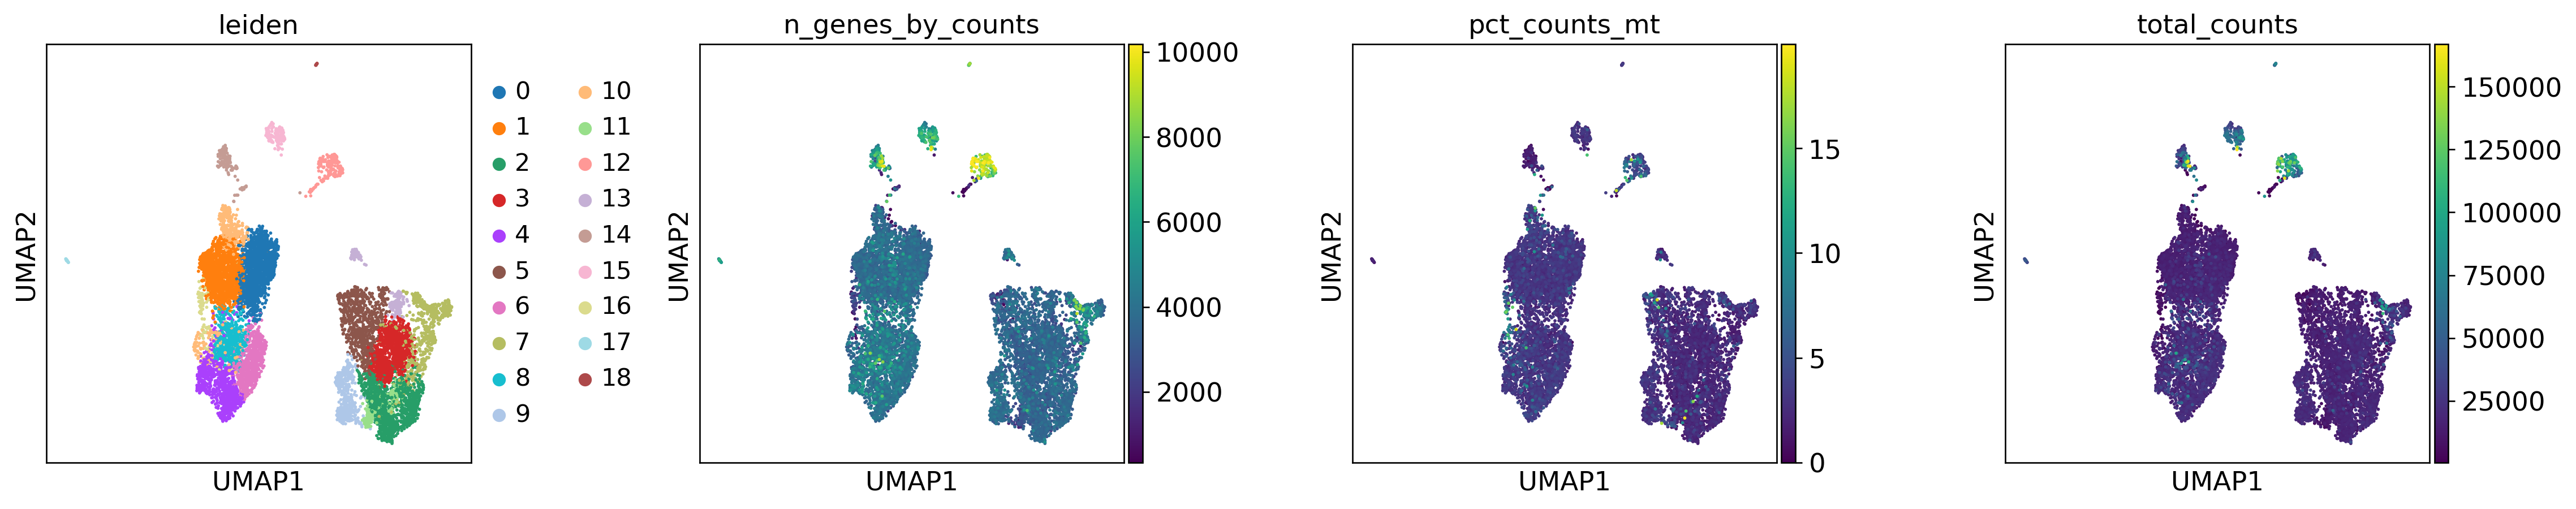

In [11]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden", resolution=1.0)

sc.pl.pca_variance_ratio(adata, log=True, show=False); plt.show()
sc.pl.umap(adata, color=["leiden","n_genes_by_counts","pct_counts_mt","total_counts"], wspace=0.4, show=False); plt.show()


## Contexte biologique — Mélanome (Dissociated Tumor Cells)
Populations attendues :
- **Mélanome (lignée mélanocytaire)** : SOX10, MITF, MLANA, PMEL, TYRP1, DCT.
  - Deux états fréquents : *MITF^high / mélanocytaire* vs *AXL^high / invasif-mésenchymal* (MITF^low).
- **Kératinocytes** : KRT14/KRT5 (basaux), KRT1/KRT10 (suprabasaux), KRT8/18/19 (épithélial simple).
- **Stroma** : CAF/fibro (COL1A1/A2, DCN, LUM; myoCAF: ACTA2, TAGLN), endothéliales (PECAM1, VWF, KDR), péricytes (RGS5, PDGFRB).
- **Immunes** :
  - T CD4 (IL7R, CCR7) ; T CD8 cytotoxiques (CD8A/B, GZMB, PRF1, NKG7) ; T “exhausted” (PDCD1, LAG3, TIGIT, HAVCR2).
  - B (MS4A1/CD79A) ; plasmocytes (MZB1, JCHAIN, XBP1).
  - Myéloïdes (LYZ, LST1, FCGR3A, MS4A7 ; S100A8/A9 neutro-like), DC (FCER1A, CLEC10A), pDC (LILRA4).
Objectif : annoter les clusters Leiden avec ces repères et interpréter le microenvironnement tumoral.


In [12]:
# Panneaux de gènes (mélanome + TME)
melanoma_core = ["SOX10","MITF","PMEL","MLANA","TYRP1","DCT"]
axl_program   = ["AXL","NGFR","ITGA6","ITGB1","FERMT2","COL1A1","COL1A2","FN1"]
keratinocytes = ["KRT14","KRT5","KRT1","KRT10","KRT8","KRT18","KRT19","EPCAM"]

caf_fibro     = ["COL1A1","COL1A2","DCN","LUM","PDGFRA"]
myo_caf       = ["ACTA2","TAGLN","MYL9"]
endothelial   = ["PECAM1","VWF","KDR","CLDN5"]
pericytes     = ["RGS5","MCAM","PDGFRB"]

t_cd4         = ["IL7R","CCR7","LTB"]
t_cd8_cyto    = ["CD8A","CD8B","GZMB","PRF1","NKG7","GNLY"]
t_exhaust     = ["PDCD1","LAG3","TIGIT","CTLA4","HAVCR2"]
b_cells       = ["MS4A1","CD79A","BANK1"]
plasma        = ["MZB1","JCHAIN","XBP1","SDC1"]
myeloid       = ["LYZ","LST1","FCGR3A","MS4A7","S100A8","S100A9","CTSS"]
dc_conv       = ["FCER1A","CLEC10A"]
pdc           = ["LILRA4","IRF7","GZMB"]

marker_dict = {
    "Melanoma_core": melanoma_core,
    "AXL_prog":      axl_program,
    "Keratinocytes": keratinocytes,
    "CAF":           caf_fibro,
    "myoCAF":        myo_caf,
    "Endothelial":   endothelial,
    "Pericytes":     pericytes,
    "T_CD4":         t_cd4,
    "T_CD8_cyt":     t_cd8_cyto,
    "T_exhaust":     t_exhaust,
    "B_cells":       b_cells,
    "Plasma":        plasma,
    "Myeloid":       myeloid,
    "cDC":           dc_conv,
    "pDC":           pdc,
}

# Dotplot (lisible pour README)
sc.pl.dotplot(
    adata, marker_dict, groupby="leiden",
    standard_scale="var", dendrogram=True, show=False, save="_melanoma_TME"
); plt.show()

# UMAP de quelques gènes pivots
sc.pl.umap(
    adata,
    color=["SOX10","MITF","AXL","MLANA","PMEL","KRT14","EPCAM","PECAM1","LYZ","CD8A"],
    ncols=5, show=False, save="_key_markers"
); plt.show()


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`
categories: 0, 1, 2, etc.
var_group_labels: Melanoma_core, AXL_prog, Keratinocytes, etc.


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:12)


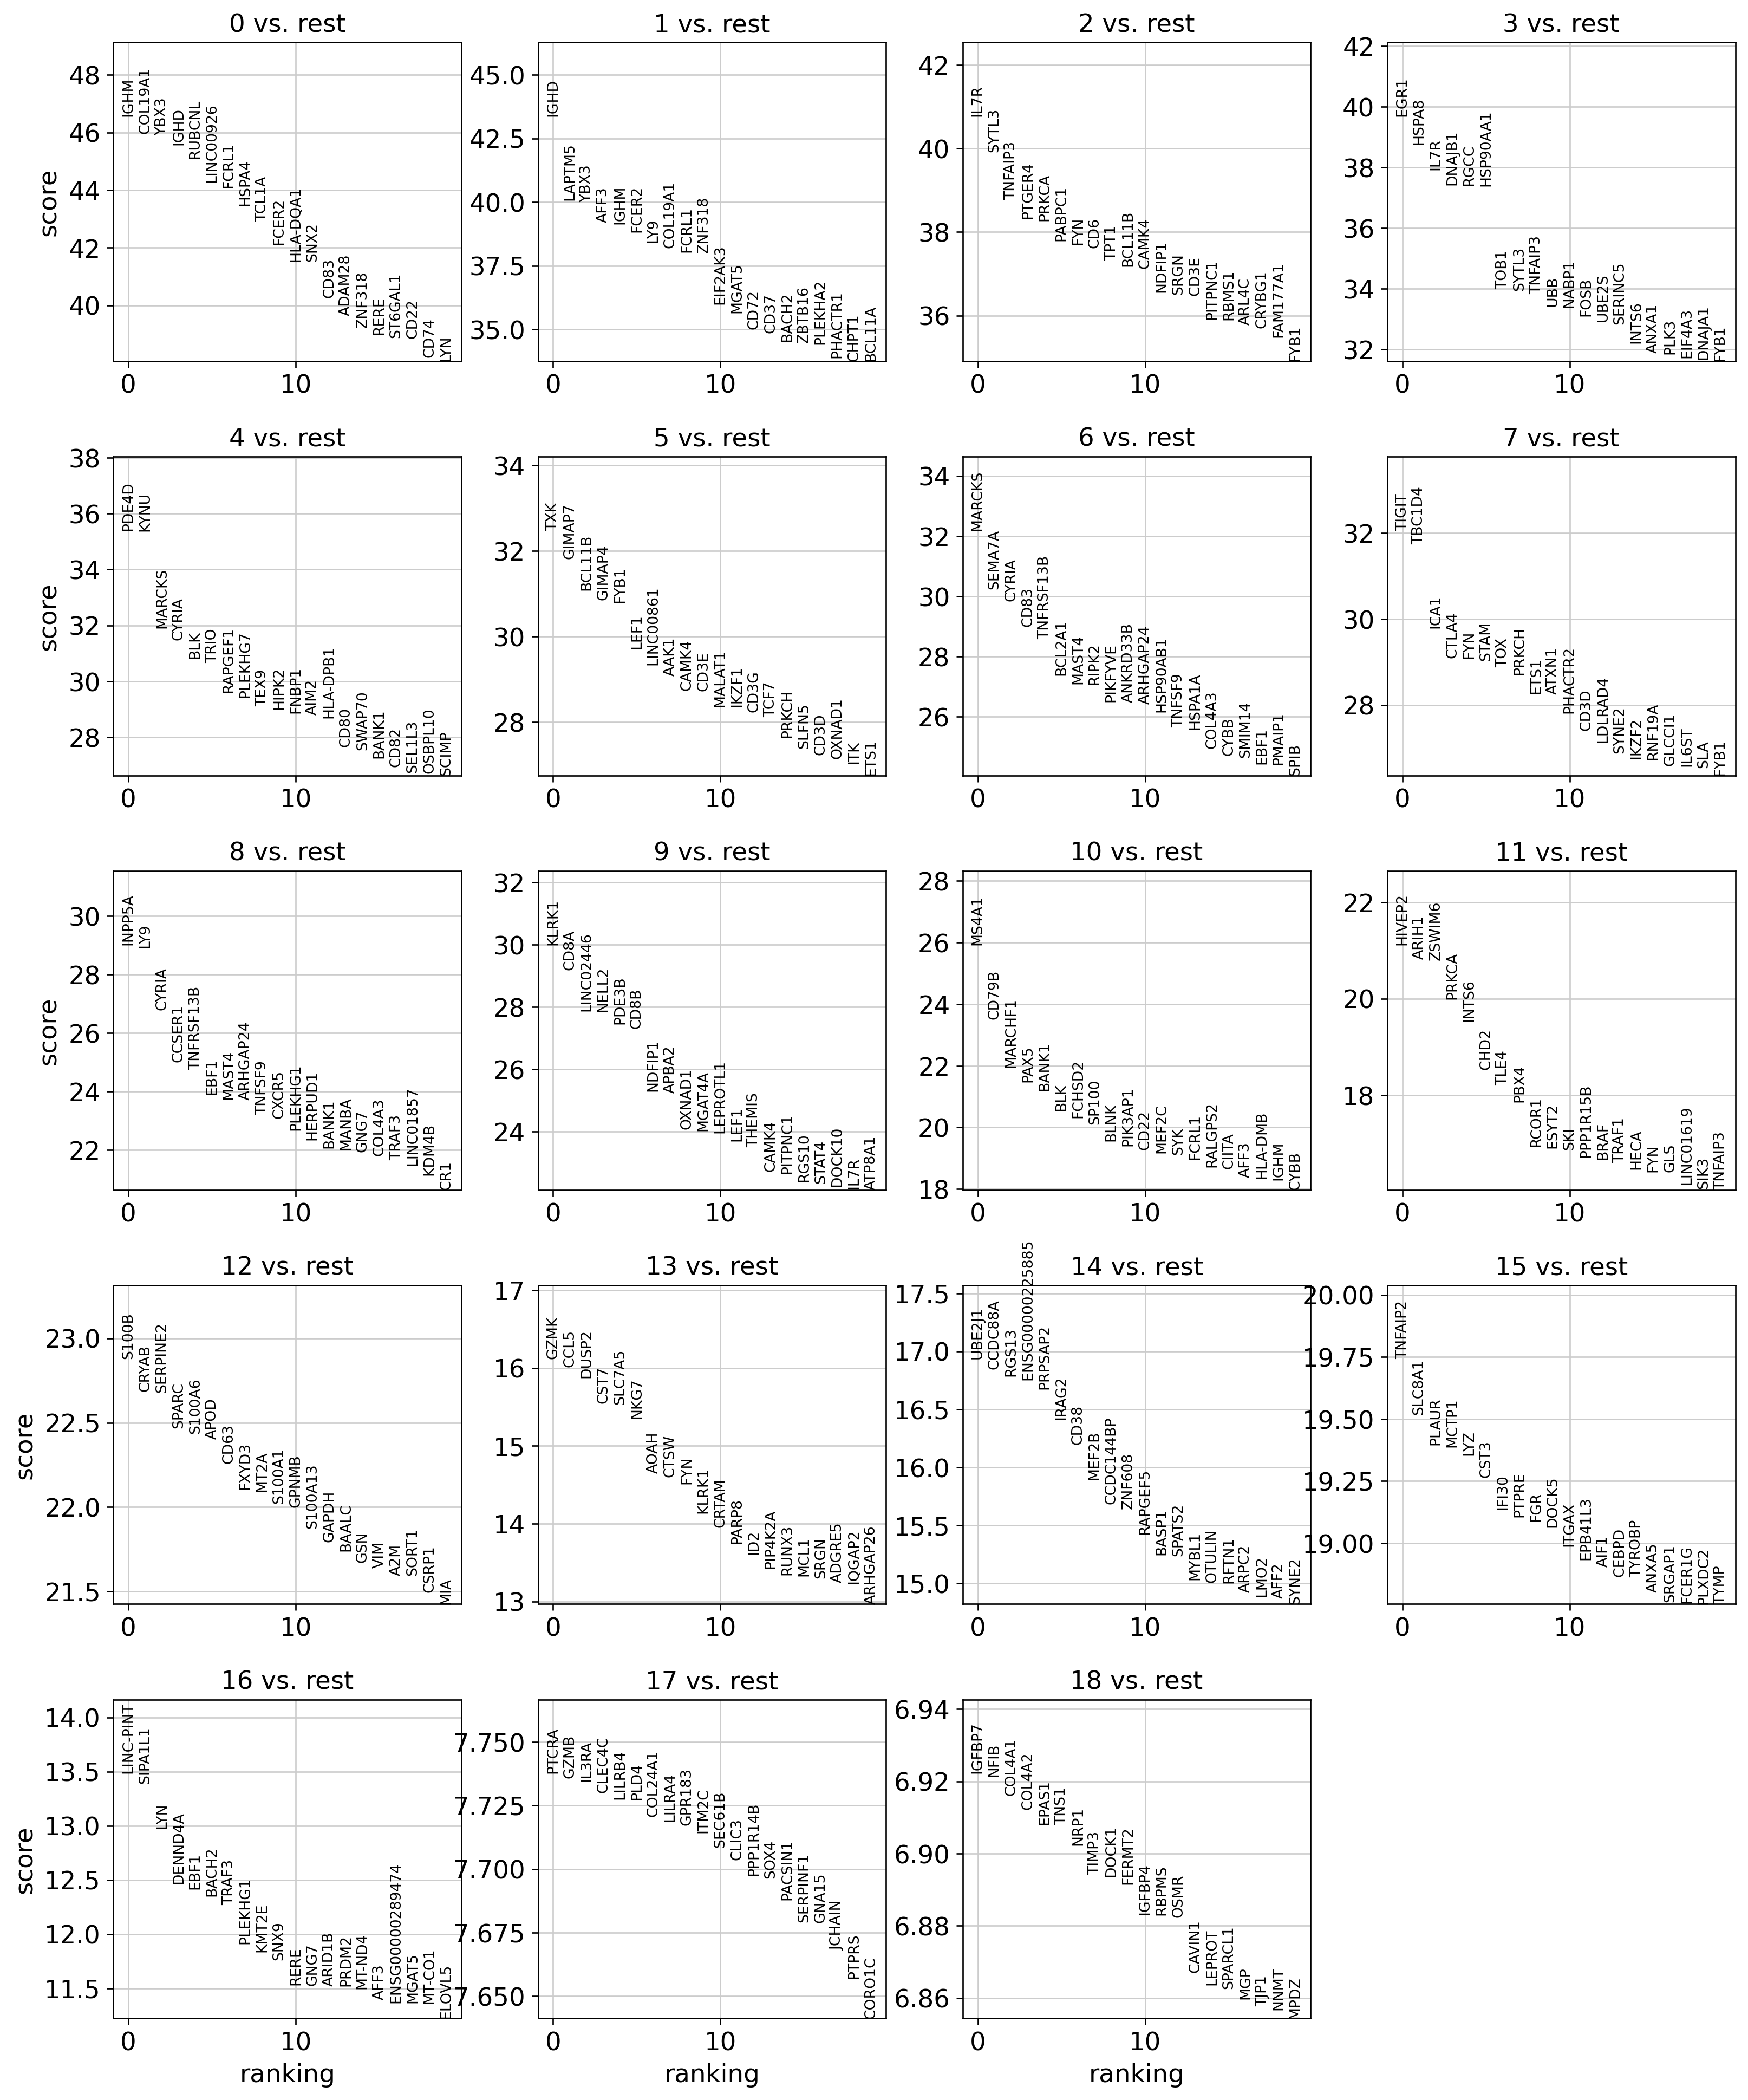

In [13]:
# Marqueurs (Wilcoxon)
sc.tl.rank_genes_groups(
    adata, groupby="leiden", method="wilcoxon",
    corr_method="benjamini-hochberg", n_genes=100
)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False, show=False); plt.show()

# Export complet + top-10/cluster
os.makedirs("artifacts", exist_ok=True)
df_all = sc.get.rank_genes_groups_df(adata, None)
df_all.to_csv("artifacts/rank_genes_leiden_all.csv", index=False)

for cl in sorted(adata.obs["leiden"].unique(), key=lambda x: int(x)):
    sc.get.rank_genes_groups_df(adata, group=cl).head(10)\
      .to_csv(f"artifacts/top10_cluster_{cl}.csv", index=False)

# UMAP final + sauvegarde .h5ad
os.makedirs("data/anndata", exist_ok=True)
sc.pl.umap(adata, color=["leiden"], save="_leiden.png", show=False)
adata.write("data/anndata/sample_hvgs_processed.h5ad", compression="gzip")


### Annotation par scores de gènes

In [14]:
# ---- Scores de modules (réutilise les panels déjà définis dans ta Cellule 2) ----
# Si tu as exécuté la Cellule 2, tu as déjà ces variables : 
# melanoma_core, axl_program, keratinocytes, caf_fibro, endothelial

use_raw = getattr(adata, "raw", None) is not None

def score_module(name, genes):
    genes_in = [g for g in genes if g in (adata.raw.var_names if use_raw else adata.var_names)]
    if len(genes_in)==0:
        adata.obs[f"score_{name}"] = 0
    else:
        sc.tl.score_genes(adata, gene_list=genes_in, score_name=f"score_{name}", use_raw=use_raw)

# Panels principaux
score_module("melanoma_core", melanoma_core)
score_module("axl_prog",      axl_program)
score_module("keratinocyte",  keratinocytes)
score_module("fibro",         caf_fibro)
score_module("endo",          endothelial)

# Petit panel "immune" générique pour contraster
score_module("immune", ["PTPRC","CD3D","CD3E","CD8A","CD79A"])

# Heuristique "cellule tumorale probable" = haut 'melanoma_core' & bas 'immune'
m = adata.obs["score_melanoma_core"]
i = adata.obs["score_immune"]
adata.obs["is_malignant_heur"] = (m > m.quantile(0.75)) & (i < i.quantile(0.50))

# Viz de contrôle
sc.pl.umap(
    adata, color=["leiden","score_melanoma_core","score_axl_prog","is_malignant_heur"],
    wspace=0.4, show=False, save="_malignancy_scores"
); plt.show()


computing score 'score_melanoma_core'
    finished: added
    'score_melanoma_core', score of gene set (adata.obs).
    250 total control genes are used. (0:00:00)
computing score 'score_axl_prog'
    finished: added
    'score_axl_prog', score of gene set (adata.obs).
    249 total control genes are used. (0:00:00)
computing score 'score_keratinocyte'
    finished: added
    'score_keratinocyte', score of gene set (adata.obs).
    400 total control genes are used. (0:00:00)
computing score 'score_fibro'
    finished: added
    'score_fibro', score of gene set (adata.obs).
    200 total control genes are used. (0:00:00)
computing score 'score_endo'
    finished: added
    'score_endo', score of gene set (adata.obs).
    150 total control genes are used. (0:00:00)
computing score 'score_immune'
    finished: added
    'score_immune', score of gene set (adata.obs).
    150 total control genes are used. (0:00:00)


### Assigner un label par cluster + figure UMAP annotée

In [15]:
# ---- Annotation simple par cluster (label = panel au score moyen max) ----
panels = ["melanoma_core","axl_prog","keratinocyte","fibro","endo","immune"]
score_cols = [f"score_{p}" for p in panels if f"score_{p}" in adata.obs.columns]

cluster_labels = {}
for cl, sub in adata.obs.groupby("leiden"):
    means = sub[score_cols].mean()
    label = means.idxmax().replace("score_","") if len(means) else "Unknown"
    cluster_labels[cl] = label

adata.obs["annot"] = adata.obs["leiden"].map(cluster_labels)

# UMAP annoté (figure pour README/CV)
sc.pl.umap(adata, color=["annot","leiden"], show=False, save="_annot"); plt.show()

# Résumés & sauvegardes "finales"
import os, pandas as pd
os.makedirs("artifacts", exist_ok=True)
pd.Series(cluster_labels, name="label").to_csv("artifacts/cluster_labels.csv")

counts = (adata.obs.groupby(["leiden","annot"]).size()
          .reset_index(name="n_cells"))
counts.to_csv("artifacts/cluster_counts.csv", index=False)

os.makedirs("data/anndata", exist_ok=True)
adata.write("data/anndata/sample_hvgs_annotated.h5ad", compression="gzip")

print("OK : figures/umap_annot.png + artifacts/* + data/anndata/sample_hvgs_annotated.h5ad")


/tmp/ipykernel_3510404/1702238246.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cl, sub in adata.obs.groupby("leiden"):
/tmp/ipykernel_3510404/1702238246.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (adata.obs.groupby(["leiden","annot"]).size()


OK : figures/umap_annot.png + artifacts/* + data/anndata/sample_hvgs_annotated.h5ad


### Heatmap de vérif (top-gènes par cluster) + exports

In [16]:
# Calcule explicitement le dendrogramme (plus propre que l’auto)
sc.tl.dendrogram(
    adata,
    groupby="leiden",
    use_rep="X_pca",
    n_pcs=30,              # tu peux laisser 50 si tu veux
    linkage_method="ward"  # ward = lisible pour heatmaps
)



Storing dendrogram info using `.uns['dendrogram_leiden']`


In [17]:
# Sélectionne un sous-ensemble de clusters si besoin (ex: les 8 premiers)
clusters = [str(i) for i in sorted(adata.obs["leiden"].astype(int).unique())][:8]

# Fixe n_genes pour rester ≤ 50 gènes au total (labels visibles)
n_genes = max(1, 50 // len(clusters))

sc.pl.rank_genes_groups_heatmap(
    adata,
    groupby="leiden",
    groups=clusters,      # <= limite l’affichage à ces clusters
    n_genes=n_genes,      # <= pour rester sous 50 gènes
    use_raw=True,         # lisible (on avait mis adata.raw avant)
    swap_axes=True,
    show_gene_labels=True,
    show=False,
    save="_topgenes.png"
); plt.show()


categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 2, etc.


In [18]:
# Dotplot : très lisible et “publication-ready”
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden",
    groups=clusters,
    n_genes=3,       # 2–5 marche bien
    standard_scale="var",
    show=False,
    save="_topgenes_dotplot.png"
); plt.show()


categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 2, etc.
